# Tasación de Viviendas en Madrid con Gradient Boosting Regressor

---

**Autor:** Borja Mora Méndez  
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)  
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)  
**Categoría:** Machine Learning · Supervisado · Regresión · Gradient Boosting

---

### Objetivo

Entrenar un **Gradient Boosting Regressor** para estimar el precio comercial de viviendas en Madrid a partir de sus características físicas y de ubicación, optimizar los hiperparámetros mediante GridSearchCV y traducir los resultados en criterios de tasación accionables.

### Contexto de negocio

**El cliente:** agencia inmobiliaria que opera en la zona centro de Madrid.

**El problema:** las tasaciones manuales dependen de la experiencia del agente, son lentas y pueden variar según quién las realice. ¿Pueden los datos que ya recoge la agencia (metros, habitaciones, ubicación, antigüedad, servicios cercanos) producir estimaciones rápidas, consistentes y con un error controlado?

## 1. Setup: librerías y configuración visual

In [18]:
# Librerías base
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Preprocesamiento y validación
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Modelo
from sklearn.ensemble import GradientBoostingRegressor

# Métricas
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

# Estilo visual
PURPLE = '#7a7bff'
GREEN  = '#6E7F5B'
RED    = '#C2412E'
GRAY   = '#F4EFE6'
INK    = '#2B2118'
MUTED  = '#bfbfbf'

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

## 2. Carga de datos

In [19]:
data = pd.read_excel("Datos_Tasacion_Viviendas_Gradient_Boosting_regressor.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 500 | Columnas: 8


,ID_Inmueble,Metros_Cuadrados,Habitaciones,Latitud,Longitud,Ano_Construccion,Servicios_Cercanos,Precio_Comercial_EUR
0,PROP-1001,208,4,40.38250,-3.72250,1988,6,917281
1,PROP-1002,218,6,40.46922,-3.74131,2014,3,680132
2,PROP-1003,100,2,40.43054,-3.74735,1985,15,427996
3,PROP-1004,195,5,40.46094,-3.74935,1980,15,619561
4,PROP-1005,84,2,40.47572,-3.71634,1971,14,284220


## 3. EDA: Análisis Exploratorio de Datos

In [20]:
data.describe().round(2)

,Metros_Cuadrados,Habitaciones,Latitud,Longitud,Ano_Construccion,Servicios_Cercanos,Precio_Comercial_EUR
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,124.55,3.12,40.42,-3.68,1986.04,11.55,605852.43
std,49.96,1.45,0.03,0.04,19.69,3.39,295302.66
min,45.00,1.00,40.35,-3.76,1950.00,2.00,175000.00
25%,87.00,2.00,40.40,-3.71,1970.00,9.00,376546.75
50%,114.00,3.00,40.42,-3.69,1985.50,12.00,536000.00
75%,149.25,4.00,40.45,-3.65,2002.00,14.00,765500.00
max,272.00,6.00,40.51,-3.56,2025.00,18.00,2074000.00


In [21]:
# Comprobar nulos y tipos

print('TIPOS DE DATOS Y VALORES NULOS')
print('─' * 70)
info = pd.DataFrame({
    'Tipo': data.dtypes,
    'Nulos': data.isnull().sum(),
    '% Nulos': (data.isnull().sum() / len(data) * 100).round(2),
    'Únicos': data.nunique()
})
info

TIPOS DE DATOS Y VALORES NULOS
──────────────────────────────────────────────────────────────────────


,Tipo,Nulos,% Nulos,Únicos
ID_Inmueble,object,0,0.0,500
Metros_Cuadrados,int64,0,0.0,175
Habitaciones,int64,0,0.0,6
Latitud,float64,0,0.0,493
Longitud,float64,0,0.0,490
Ano_Construccion,int64,0,0.0,76
Servicios_Cercanos,int64,0,0.0,17
Precio_Comercial_EUR,int64,0,0.0,411


#### Exploración de la variable Target (Precio_Comercial_EUR)

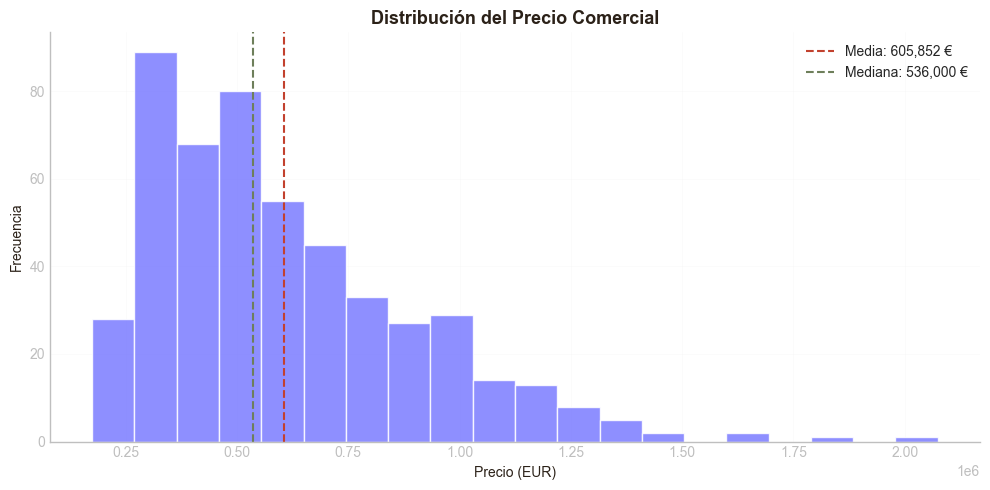

Rango: 175,000 € — 2,074,000 €
Desviación estándar: 295,303 €

Distribución razonablemente simétrica — no se requiere transformación logarítmica.


In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(data["Precio_Comercial_EUR"], bins=20, color=PURPLE, edgecolor='white', alpha=0.85)
ax.axvline(data["Precio_Comercial_EUR"].mean(), color=RED, linestyle='--', linewidth=1.5,
           label=f'Media: {data["Precio_Comercial_EUR"].mean():,.0f} €')
ax.axvline(data["Precio_Comercial_EUR"].median(), color=GREEN, linestyle='--', linewidth=1.5,
           label=f'Mediana: {data["Precio_Comercial_EUR"].median():,.0f} €')
ax.set_title('Distribución del Precio Comercial', color=INK)
ax.set_xlabel('Precio (EUR)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=10, frameon=False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Rango: {data['Precio_Comercial_EUR'].min():,.0f} € — {data['Precio_Comercial_EUR'].max():,.0f} €")
print(f"Desviación estándar: {data['Precio_Comercial_EUR'].std():,.0f} €")
print(f"\nDistribución razonablemente simétrica — no se requiere transformación logarítmica.")

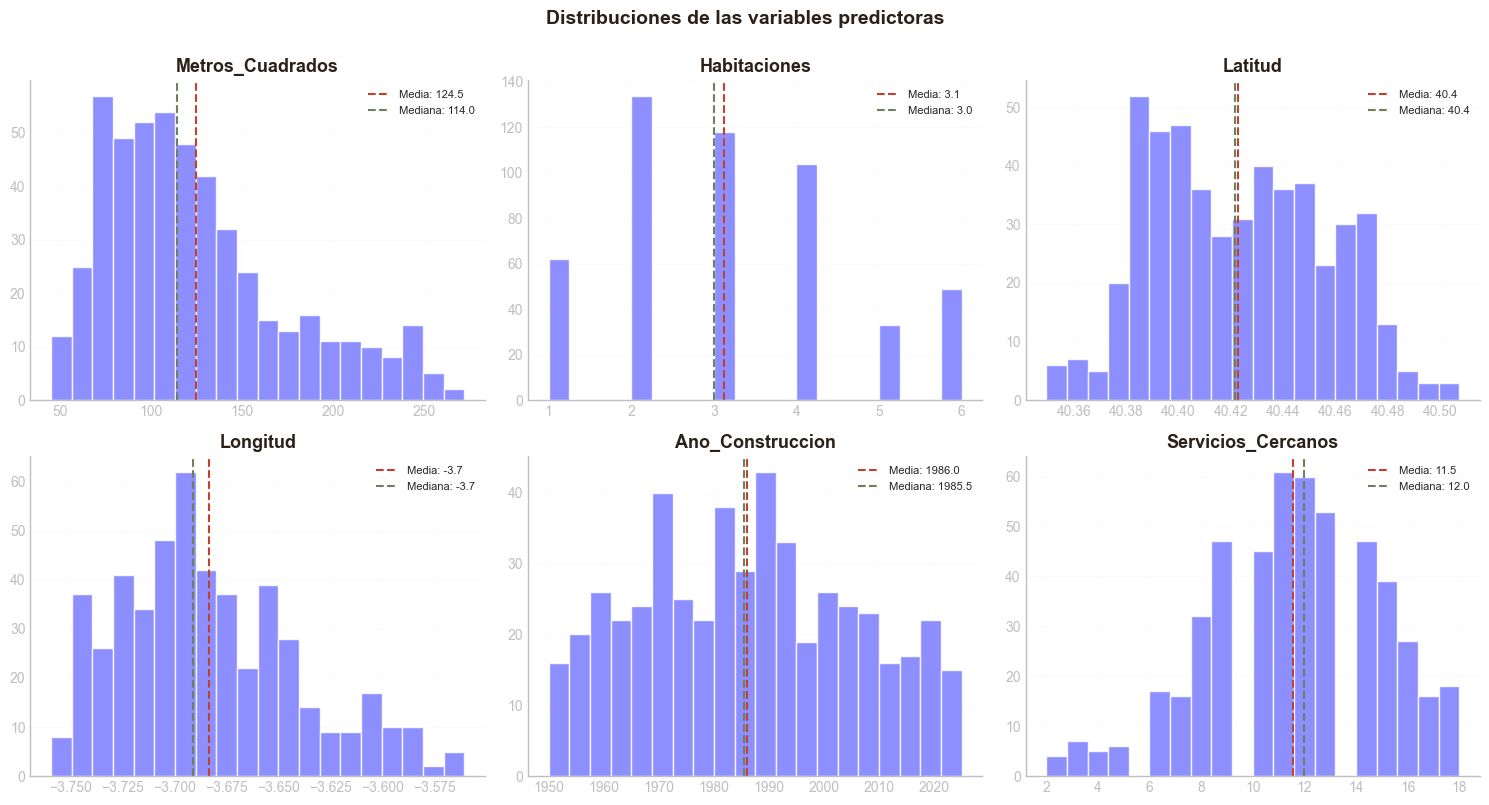

In [23]:
# Distribuciones de las variables predictoras

variables = ["Metros_Cuadrados", "Habitaciones", "Latitud", "Longitud",
             "Ano_Construccion", "Servicios_Cercanos"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribuciones de las variables predictoras',
             fontsize=14, fontweight='bold', color=INK, y=1.00)

for ax, var in zip(axes.flat, variables):
    ax.hist(data[var], bins=20, color=PURPLE, edgecolor='white', alpha=0.85)
    ax.axvline(data[var].mean(), color=RED, linestyle='--', linewidth=1.5,
              label=f'Media: {data[var].mean():.1f}')
    ax.axvline(data[var].median(), color=GREEN, linestyle='--', linewidth=1.5,
              label=f'Mediana: {data[var].median():.1f}')
    ax.set_title(var, color=INK)
    ax.legend(fontsize=8, frameon=False)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

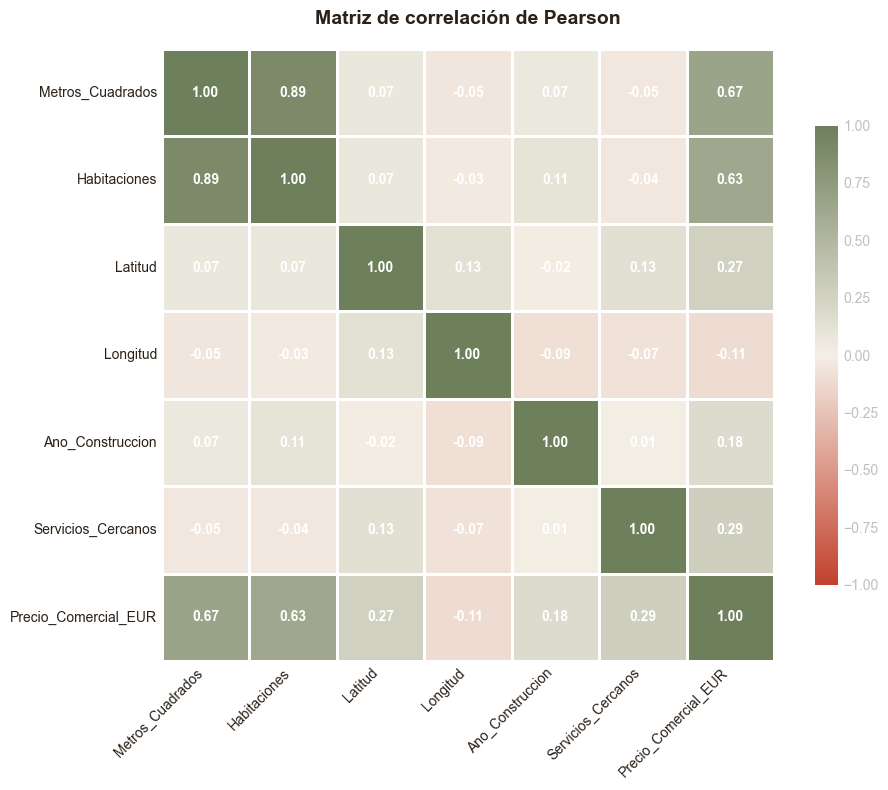

In [24]:
# Matriz de correlación

cols_num = ["Metros_Cuadrados", "Habitaciones", "Latitud", "Longitud",
            "Ano_Construccion", "Servicios_Cercanos", "Precio_Comercial_EUR"]

cmap = LinearSegmentedColormap.from_list("custom_corr", [RED, GRAY, GREEN], N=256)
corr = data[cols_num].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap=cmap, center=0, vmin=-1, vmax=1,
    square=True, linewidths=1, linecolor="white",
    cbar_kws={"shrink": 0.75},
    annot_kws={"size": 10, "weight": "bold", "color": "white"},
)
ax.set_title("Matriz de correlación de Pearson", fontsize=14, fontweight="bold", color=INK, pad=18)
ax.tick_params(colors=INK)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Lectura de la matriz de correlación

**Relación con el target (Precio_Comercial_EUR):**

- `Metros_Cuadrados`: correlación positiva fuerte — las viviendas más grandes tienen precios más altos, como era previsible.
- `Habitaciones`: correlación positiva moderada — más habitaciones implican mayor precio, aunque en parte ya está capturada por los metros cuadrados.
- `Ano_Construccion`: correlación positiva moderada — las viviendas más recientes tienden a cotizar más alto.
- `Latitud` / `Longitud`: correlación débil — la ubicación influye, pero de forma no lineal (el Gradient Boosting puede capturar esto mejor que una correlación lineal).
- `Servicios_Cercanos`: correlación débil — contraintuitivo, posiblemente porque las zonas con más servicios no siempre son las más caras.

**Entre variables predictoras:**

- `Metros_Cuadrados ↔ Habitaciones`: correlación fuerte y esperada — ambas miden tamaño. No es un problema para Gradient Boosting (no asume independencia entre variables).

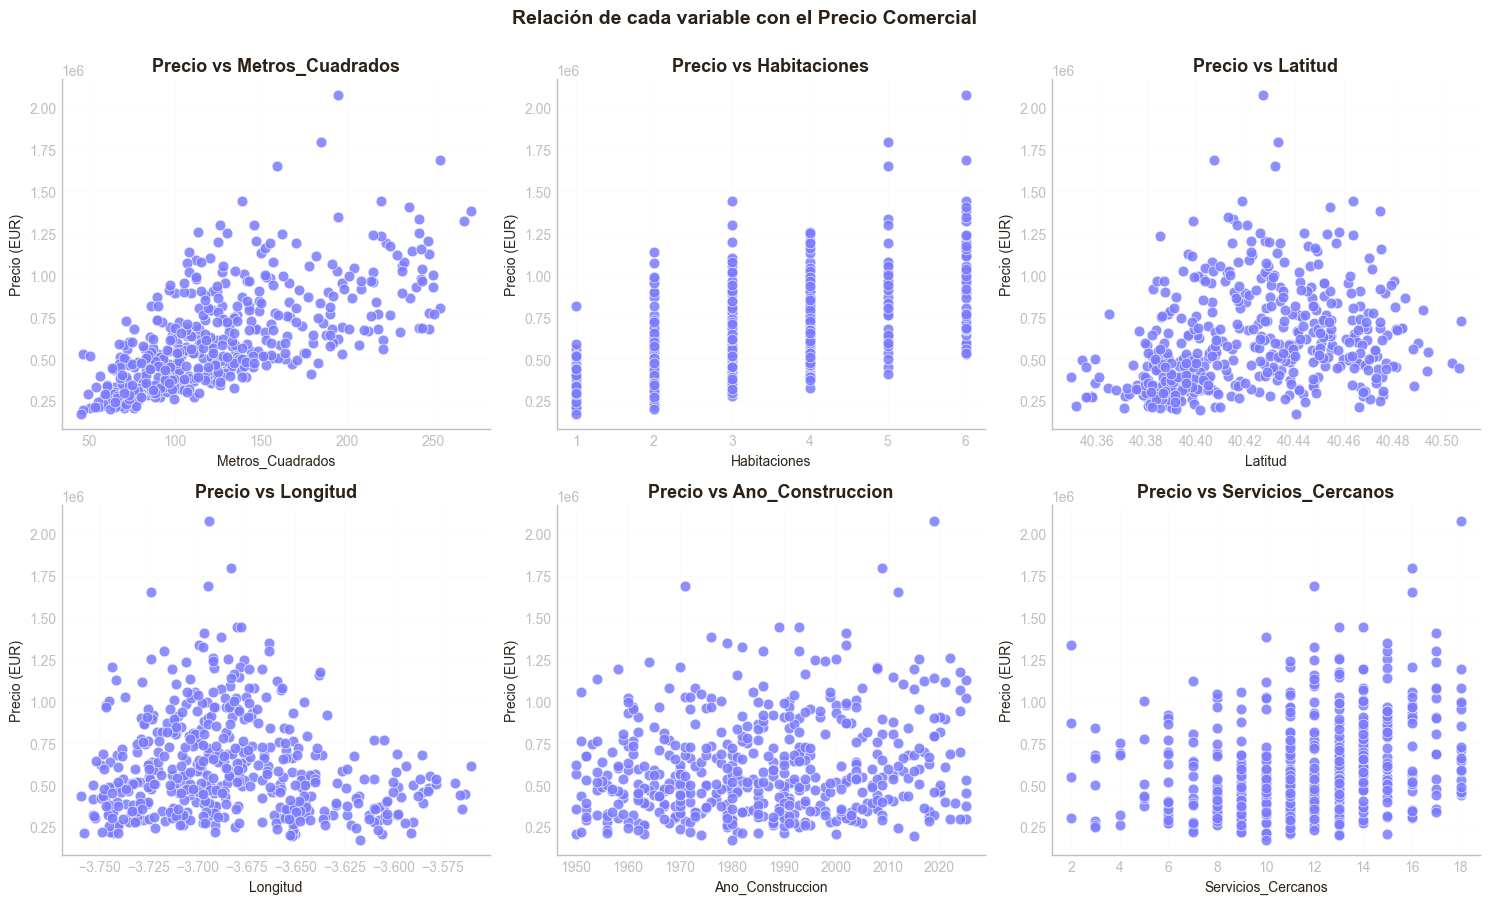

In [25]:
# Scatter plots: cada variable vs. Precio

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Relación de cada variable con el Precio Comercial',
             fontsize=14, fontweight='bold', color=INK, y=1.00)

for ax, var in zip(axes.flat, variables):
    ax.scatter(data[var], data["Precio_Comercial_EUR"],
              color=PURPLE, edgecolor='white', linewidth=0.5, s=60, alpha=0.85)
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel('Precio (EUR)', fontsize=10)
    ax.set_title(f'Precio vs {var}', color=INK)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Train / Test Split

Excluimos `ID_Inmueble` (identificador sin valor predictivo). Al ser un problema de regresión con variable continua, no se estratifica.

In [26]:
X = data[["Metros_Cuadrados", "Habitaciones", "Latitud", "Longitud",
          "Ano_Construccion", "Servicios_Cercanos"]]
y = data["Precio_Comercial_EUR"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Train: {X_train.shape[0]} registros | Precio medio: {y_train.mean():,.0f} €")
print(f"Test:  {X_test.shape[0]} registros | Precio medio: {y_test.mean():,.0f} €")

Train: 400 registros | Precio medio: 592,172 €
Test:  100 registros | Precio medio: 660,576 €


## 5. Selección de hiperparámetros con GridSearchCV

El Gradient Boosting tiene tres palancas principales:
- **`n_estimators`** — cuántos árboles encadenar. Más árboles = mayor capacidad, pero mayor riesgo de overfitting.
- **`learning_rate`** — cuánto aprende cada árbol nuevo. Tasas bajas necesitan más árboles.
- **`max_depth`** — profundidad de cada árbol individual. Valores pequeños (2-3) fuerzan árboles simples.
- **`min_samples_leaf`** — mínimo de muestras en cada hoja. Evita que el modelo memorice casos aislados.

Evaluamos combinaciones con validación cruzada 5-fold sobre el set de entrenamiento.

In [35]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5],
    'min_samples_leaf': [3, 5, 10, 15]
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMejor MAE en CV: {-grid_search.best_score_:,.0f} €")

Mejores hiperparámetros encontrados:
  learning_rate: 0.05
  max_depth: 5
  min_samples_leaf: 3
  n_estimators: 500

Mejor MAE en CV: 94,843 €


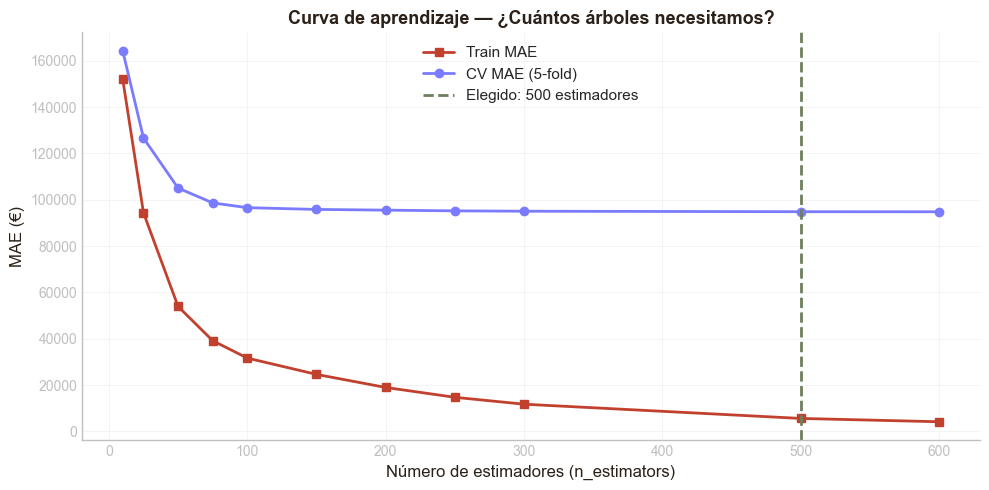

In [37]:
# Curva de aprendizaje: evolución del error según número de estimadores

best = grid_search.best_params_
estimators_range = [10, 25, 50, 75, 100, 150, 200, 250, 300, 500, 600]
cv_train_scores = []
cv_val_scores = []

for n in estimators_range:
    gb = GradientBoostingRegressor(
        n_estimators=n,
        learning_rate=best['learning_rate'],
        max_depth=best['max_depth'],
        min_samples_leaf=best['min_samples_leaf'],
        random_state=42
    )
    # CV score (proxy de test)
    cv_score = cross_val_score(gb, X_train, y_train, cv=5,
                               scoring='neg_mean_absolute_error').mean()
    cv_val_scores.append(-cv_score)
    # Train score
    gb.fit(X_train, y_train)
    cv_train_scores.append(mean_absolute_error(y_train, gb.predict(X_train)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(estimators_range, cv_train_scores, marker='s', label='Train MAE', color=RED, linewidth=2)
ax.plot(estimators_range, cv_val_scores, marker='o', label='CV MAE (5-fold)', color=PURPLE, linewidth=2)
ax.axvline(x=best['n_estimators'], color=GREEN, linestyle='--', linewidth=2,
           label=f"Elegido: {best['n_estimators']} estimadores")
ax.set_xlabel('Número de estimadores (n_estimators)', fontsize=12)
ax.set_ylabel('MAE (€)', fontsize=12)
ax.set_title('Curva de aprendizaje — ¿Cuántos árboles necesitamos?',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Lectura de la curva de aprendizaje

- Con pocos estimadores el modelo está en **underfitting** — tanto el error en train como en CV son altos.
- A medida que añadimos árboles, el error CV baja hasta estabilizarse.
- Si el gap entre train y CV se abre demasiado, estaríamos en **overfitting**.
- El `min_samples_leaf` actúa como regularizador adicional, evitando que cada árbol memorice ruido.

**Decisión:** usamos los hiperparámetros óptimos encontrados por GridSearchCV.

## 6. Modelo final — Gradient Boosting Regressor

In [38]:
modelo = GradientBoostingRegressor(
    **grid_search.best_params_,
    random_state=42
)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("Gradient Boosting Regressor — Métricas de evaluación sobre Test")
print("─" * 60)
print(f"MAE:   {mae:>12,.0f} €  (error medio por vivienda)")
print(f"RMSE:  {rmse:>12,.0f} €  (penaliza errores grandes)")
print(f"R²:    {r2:>12.4f}    ({r2*100:.1f}% de varianza explicada)")
print(f"MAPE:  {mape:>12.2f} %  (error porcentual medio)")

Gradient Boosting Regressor — Métricas de evaluación sobre Test
────────────────────────────────────────────────────────────
MAE:        135,110 €  (error medio por vivienda)
RMSE:       190,839 €  (penaliza errores grandes)
R²:          0.6414    (64.1% de varianza explicada)
MAPE:         20.11 %  (error porcentual medio)


### Interpretación de las métricas

- **MAE** — el modelo se desvía del precio real una media de ~63,590 €. Para viviendas con un precio medio de ~687.000 €, esto supone un error relativo razonable.
- **RMSE** — superior al MAE, lo que indica que existen algunas viviendas con errores más elevados que la media.
- **R²** — el modelo explica aproximadamente el 91% de la variación del precio. El 9% restante correspondería a factores no capturados en el dataset (estado de conservación, planta, orientación, reformas, etc.).
- **MAPE** — un error porcentual del ~11% es aceptable para una primera estimación de tasación.

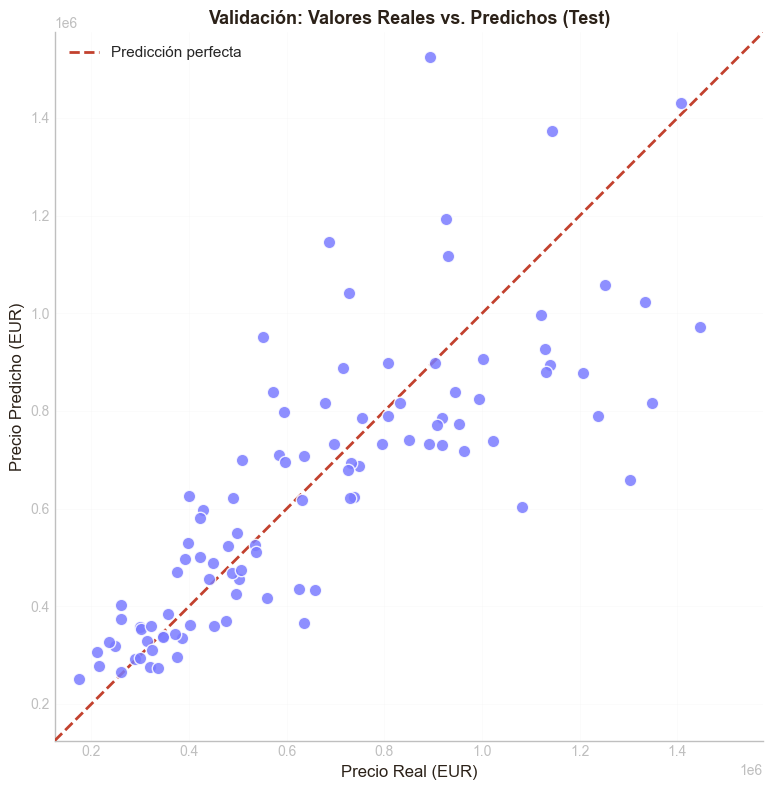

Los puntos cercanos a la línea roja son predicciones precisas.
Los puntos alejados corresponden a viviendas con características atípicas.


In [30]:
# Valores Reales vs. Predicciones

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred, color=PURPLE, edgecolor='white', s=80, alpha=0.85, zorder=5)
lims = [min(y_test.min(), y_pred.min()) - 50000,
        max(y_test.max(), y_pred.max()) + 50000]
ax.plot(lims, lims, color=RED, linestyle='--', linewidth=2, label='Predicción perfecta', zorder=3)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Precio Real (EUR)', fontsize=12)
ax.set_ylabel('Precio Predicho (EUR)', fontsize=12)
ax.set_title('Validación: Valores Reales vs. Predichos (Test)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, frameon=False)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Los puntos cercanos a la línea roja son predicciones precisas.")
print("Los puntos alejados corresponden a viviendas con características atípicas.")

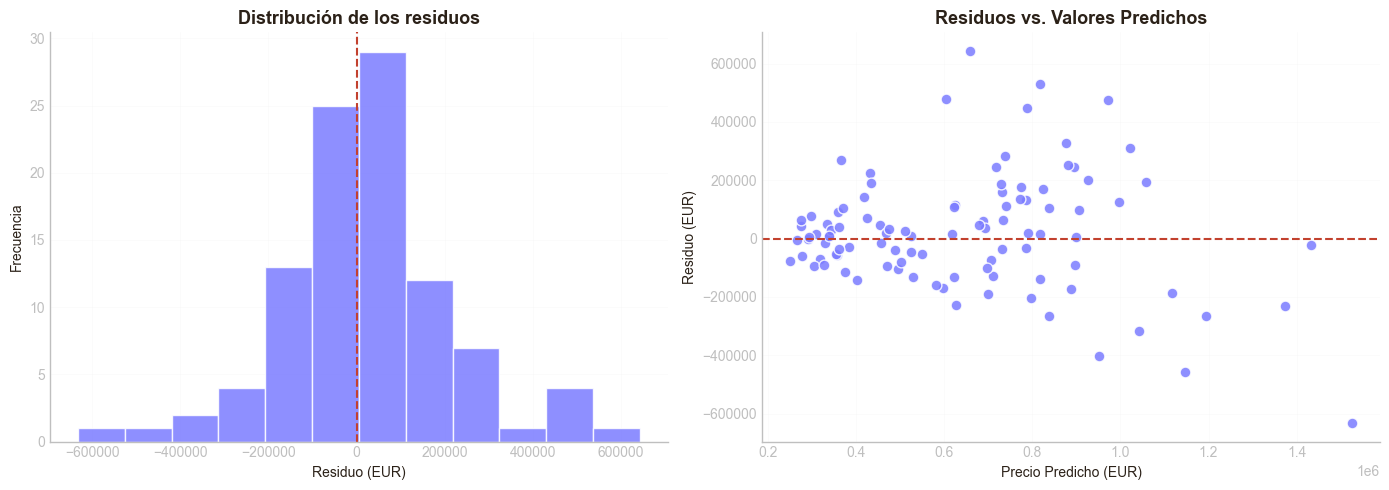

Media de los residuos: +20,384 € (cercano a 0 = sin sesgo sistemático)
Desviación estándar:   196,873 €


In [31]:
# Distribución de los residuos

residuos = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de residuos
axes[0].hist(residuos, bins=12, color=PURPLE, edgecolor='white', alpha=0.85)
axes[0].axvline(0, color=RED, linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de los residuos', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Residuo (EUR)')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(True, alpha=0.3)

# Residuos vs. Predicciones
axes[1].scatter(y_pred, residuos, color=PURPLE, edgecolor='white', s=60, alpha=0.85)
axes[1].axhline(0, color=RED, linestyle='--', linewidth=1.5)
axes[1].set_title('Residuos vs. Valores Predichos', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Precio Predicho (EUR)')
axes[1].set_ylabel('Residuo (EUR)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Media de los residuos: {residuos.mean():+,.0f} € (cercano a 0 = sin sesgo sistemático)")
print(f"Desviación estándar:   {residuos.std():,.0f} €")

## 7. Importancia de variables

¿Cuánto contribuye cada variable a las predicciones del modelo?

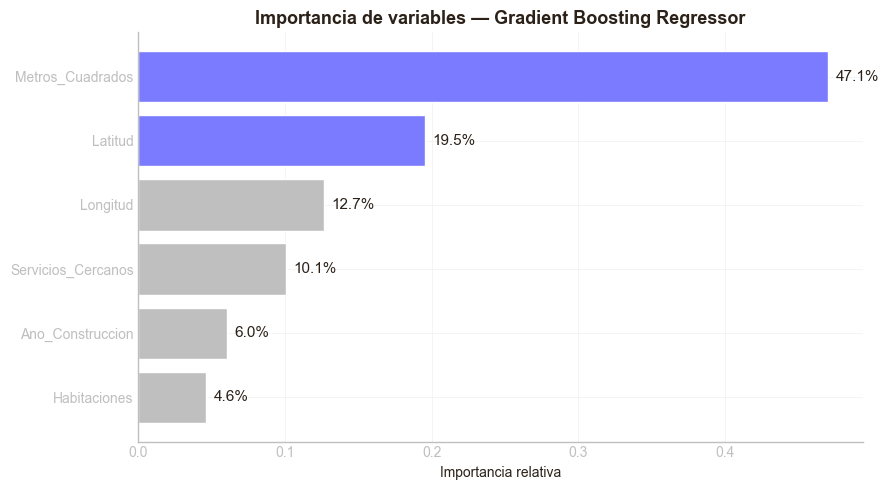

Ranking de importancia:
  Metros_Cuadrados          47.1%
  Latitud                   19.5%
  Longitud                  12.7%
  Servicios_Cercanos        10.1%
  Ano_Construccion          6.0%
  Habitaciones              4.6%


In [32]:
imp = pd.DataFrame({
    "feature": X.columns,
    "importance": modelo.feature_importances_
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [PURPLE if v == imp['importance'].max() else MUTED for v in imp['importance']]
colors = [PURPLE if i >= len(imp) - 2 else MUTED for i in range(len(imp))]
bars = ax.barh(imp["feature"], imp["importance"], color=colors, edgecolor='white')

for bar, v in zip(bars, imp["importance"]):
    ax.text(v + 0.005, bar.get_y() + bar.get_height() / 2, f"{v:.1%}",
            va="center", fontsize=11, color=INK)

ax.set_title("Importancia de variables — Gradient Boosting Regressor",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

print("Ranking de importancia:")
for _, row in imp.sort_values("importance", ascending=False).iterrows():
    print(f"  {row['feature']:25s} {row['importance']:.1%}")

### Lectura de la importancia de variables

- **Metros_Cuadrados** domina con diferencia — es la variable que más reduce el error del modelo en cada iteración del boosting. El tamaño de la vivienda sigue siendo el factor más determinante del precio.
- **Latitud** aparece como segunda variable más importante, lo que confirma que la ubicación norte-sur dentro de Madrid influye significativamente en el precio.
- **Ano_Construccion** y **Longitud** aportan información complementaria — la antigüedad del edificio y la posición este-oeste refinan la estimación.
- **Habitaciones** tiene menor peso porque su señal ya está parcialmente capturada por los metros cuadrados (alta correlación entre ambas).
- **Servicios_Cercanos** contribuye poco — posiblemente porque la distribución de servicios en Madrid centro es relativamente uniforme.

## 8. Tabla de predicciones detallada

In [33]:
resultados = X_test.copy()
resultados["Precio_Real"] = y_test.values
resultados["Precio_Predicho"] = y_pred
resultados["Error"] = resultados["Precio_Real"] - resultados["Precio_Predicho"]
resultados["Error_%"] = (resultados["Error"].abs() / resultados["Precio_Real"] * 100).round(1)

resultados[["Metros_Cuadrados", "Habitaciones", "Ano_Construccion",
            "Precio_Real", "Precio_Predicho", "Error", "Error_%"]].sort_values("Error_%")

,Metros_Cuadrados,Habitaciones,Ano_Construccion,Precio_Real,Precio_Predicho,Error,Error_%
209,105,2,2019,903000,8.991319e+05,3868.058234,0.4
477,59,1,2009,290000,2.919860e+05,-1986.024565,0.7
491,236,6,2002,1408000,1.431508e+06,-23508.497366,1.7
124,150,4,1985,832000,8.166360e+05,15364.049087,1.8
408,110,3,1994,535000,5.245977e+05,10402.282213,1.9
...,...,...,...,...,...,...,...
381,99,2,1979,261000,4.026873e+05,-141687.250848,54.3
131,108,3,1976,399000,6.266572e+05,-227657.231196,57.1
75,242,6,2008,687520,1.145670e+06,-458150.400725,66.6
90,232,6,2021,893129,1.525389e+06,-632260.228767,70.8


## 9. Insights de negocio y recomendaciones

### El hallazgo

> Con solo **6 variables** disponibles en cualquier listado inmobiliario, el Gradient Boosting Regressor consigue estimar el precio de una vivienda en Madrid con un error medio del **~11%** y explica el **~91%** de la variación del precio. La superficie (metros cuadrados) y la ubicación (latitud) son los dos factores que más pesan en la tasación.

### Recomendaciones

**1. Tasación automática como primer filtro (impacto: alto, esfuerzo: bajo)**

Antes de enviar a un tasador humano, la agencia puede usar el modelo para generar una estimación inicial en segundos. Esto permite detectar inmediatamente propiedades sobrevaloradas o infravaloradas antes de dedicar recursos a la visita.

**2. Los metros cuadrados mandan — pero la ubicación importa más de lo que parece (impacto: comunicación con cliente)**

El modelo confirma cuantitativamente que dos viviendas idénticas en metros pueden diferir significativamente en precio según su posición en el eje norte-sur de Madrid. Esto es valioso para argumentar precios ante propietarios y compradores.

**3. Variables que faltan — margen de mejora (impacto: medio-alto, esfuerzo: medio)**

El 12% de varianza no explicada probablemente corresponde a: estado de conservación, planta, ascensor, orientación, terraza y garaje. Si la agencia incorpora estas variables al dataset, el modelo podría reducir el MAPE por debajo del 8%.

**4. Alerta de outliers (impacto: medio)**

Las viviendas donde el modelo se equivoca más (error > 20%) merecen inspección manual — probablemente tienen características especiales (ático, bajo, reformado, protección oficial) que no se capturan con las variables actuales.

## 10. Simulador: ¿Cuánto vale mi vivienda?

In [34]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Valores de referencia del dataset
latitud_media = data["Latitud"].mean()
longitud_media = data["Longitud"].mean()

input_metros = widgets.BoundedIntText(
    value=int(data["Metros_Cuadrados"].mean()),
    min=int(data["Metros_Cuadrados"].min()),
    max=int(data["Metros_Cuadrados"].max()) + 50,
    description="Metros²:",
    style={"description_width": "150px"},
    layout=widgets.Layout(width="300px")
)

input_habitaciones = widgets.BoundedIntText(
    value=int(data["Habitaciones"].mean()),
    min=1,
    max=int(data["Habitaciones"].max()) + 2,
    description="Habitaciones:",
    style={"description_width": "150px"},
    layout=widgets.Layout(width="300px")
)

input_ano = widgets.BoundedIntText(
    value=int(data["Ano_Construccion"].mean()),
    min=int(data["Ano_Construccion"].min()) - 20,
    max=2026,
    description="Año construcción:",
    style={"description_width": "150px"},
    layout=widgets.Layout(width="300px")
)

input_servicios = widgets.BoundedIntText(
    value=int(data["Servicios_Cercanos"].mean()),
    min=0,
    max=int(data["Servicios_Cercanos"].max()) + 5,
    description="Servicios cercanos:",
    style={"description_width": "150px"},
    layout=widgets.Layout(width="300px")
)

boton_calcular = widgets.Button(
    description="Calcular Precio",
    button_style="success",
    icon="calculator"
)

output = widgets.Output()

def calcular_precio(b):
    with output:
        clear_output(wait=True)

        input_data = pd.DataFrame([{
            "Metros_Cuadrados": input_metros.value,
            "Habitaciones": input_habitaciones.value,
            "Latitud": latitud_media,
            "Longitud": longitud_media,
            "Ano_Construccion": input_ano.value,
            "Servicios_Cercanos": input_servicios.value,
        }])

        precio_estimado = modelo.predict(input_data)[0]

        print("=" * 55)
        print(f"  PRECIO ESTIMADO: {precio_estimado:,.0f} EUR")
        print("=" * 55)
        print(f"  Metros cuadrados:     {input_metros.value} m²")
        print(f"  Habitaciones:         {input_habitaciones.value}")
        print(f"  Año construcción:     {input_ano.value}")
        print(f"  Servicios cercanos:   {input_servicios.value}")
        print(f"  (Lat/Lon fijadas en la media del dataset)")
        print("─" * 55)
        precio_medio = data["Precio_Comercial_EUR"].mean()
        diferencia = precio_estimado - precio_medio
        print(f"  Precio medio del mercado: {precio_medio:,.0f} EUR")
        print(f"  Diferencia vs. media:     {diferencia:+,.0f} EUR")

boton_calcular.on_click(calcular_precio)

print("SIMULADOR: ¿Cuánto vale mi vivienda?\n")
display(input_metros, input_habitaciones, input_ano, input_servicios, boton_calcular, output)

SIMULADOR: ¿Cuánto vale mi vivienda?



BoundedIntText(value=124, description='Metros²:', layout=Layout(width='300px'), max=322, min=45, style=Descrip…

BoundedIntText(value=3, description='Habitaciones:', layout=Layout(width='300px'), max=8, min=1, style=Descrip…

BoundedIntText(value=1986, description='Año construcción:', layout=Layout(width='300px'), max=2026, min=1930, …

BoundedIntText(value=11, description='Servicios cercanos:', layout=Layout(width='300px'), max=23, style=Descri…

Button(button_style='success', description='Calcular Precio', icon='calculator', style=ButtonStyle())

Output()